####imports
# TO-DO:
- retrain best model
    - isolate test images to avoid data leakage (since split is random)
    

In [ ]:
#! pip install streamlit
#import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image
import tensorflow as tf
import keras
from keras.saving import load_model
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.applications import MobileNetV2
from keras import layers,models
from tensorflow import data as tf_data
import os
import random
import zipfile
import shutil
import pandas as pd
from sklearn.metrics import (roc_curve, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay,classification_report)
import reload_data2
#from google.colab import drive
#drive.mount('/content/drive')
import random
import Handwriting_XAI2 as xai

# Deployment Plan:
- Have file browser with test set images
    - image must not be labelled (for guessing game)
    - show demographic info. of each?
    - ~would have to clean csv~ + some writers don't have metadata
- Give model image
    - Get top three predictions
    - Show sample of each of those top 3 versus given image
    - have user guess
- Reveal if model was correct + if user was correct

* Limitations:
    * Model does not know what to do with "new" writers
    * Generally seems to "look" in the right areas (the Grad-CAM "box"), but sometimes gets stuck in whitespace
    * Images are cropped inconsistently per some classes

In [ ]:
# load model
model = tf.keras.models.load_model("/content/MobileNetV2_allclass.keras")

IMG_SIZE = (384,384)

st.title("Handwriting Identification Demo")

uploaded_file = st.file_uploader("Upload a handwriting image")

if uploaded_file:

    img = Image.open(uploaded_file).convert("RGB")
    st.image(img, caption="Uploaded Image", width=300)

    img = img.resize(IMG_SIZE)
    img = np.array(img) / 255.0
    img = np.expand_dims(img, axis=0)

    preds = model.predict(img)[0]

    top3 = np.argsort(preds)[-3:][::-1]

    st.subheader("Top 3 Predictions")

    for i, writer in enumerate(top3):
        st.write(f"{i+1}. Writer {writer} (confidence {preds[writer]:.3f})")

In [ ]:
## GUESS THE WRITER

choice = st.radio(
    "Which writer do you think it is?",
    [f"Writer {top3[0]}", f"Writer {top3[1]}", f"Writer {top3[2]}"]
)

if st.button("Submit Guess"):
    st.write("Interesting choice!")

## Preprocess CSV

In [ ]:
df = pd.read_csv("/content/CSAFE_Handwriting_Info.csv")
df.head()

,wid,agegroup,gender,hand,thirdgrade_usa,thirdgrade_usa_region,s1_dae,s1_time,s2_dae,s2_time,s3_dae,s3_time,db_version
0,180,61+,Female,Right,True,Midwest,0.0,Late Morning,28.0,Late Morning,66.0,Late Morning,version5
1,410,18-24,Female,Right,True,Midwest,0.0,Late Afternoon,32.0,Late Evening,54.0,Early Evening,version5
2,593,18-24,Male,Left,True,Midwest,0.0,Late evening (later than 7:30pm),30.0,Late evening (later than 7:30pm),61.0,Early evening (5pm-7:30pm),version5
3,520,18-24,Female,Right,True,Midwest,0.0,Late Evening,26.0,Late Morning,54.0,Late Morning,version5
4,233,18-24,Male,Right,False,NaN,340.0,Late Evening,380.0,Late Evening,0.0,Late Evening,version5


In [ ]:
#sort by writer id
df = df.sort_values(by="wid").reset_index(drop=True)
df.head()

,wid,agegroup,gender,hand,thirdgrade_usa,thirdgrade_usa_region,s1_dae,s1_time,s2_dae,s2_time,s3_dae,s3_time,db_version
0,1,25-40,female,right,True,midwest,0.0,earlyafternoon,26.0,latemorning,47.0,earlyafternoon,version5
1,2,41-60,male,right,True,midwest,0.0,latemorning,53.0,latemorning,98.0,earlyafternoon,version5
2,3,25-40,female,right,True,midwest,0.0,earlyafternoon,21.0,earlyafternoon,47.0,earlyafternoon,version5
3,4,18-24,female,ambidextrous,True,NaN,0.0,latemorning,21.0,earlyafternoon,44.0,earlymorning,version5
4,5,18-24,male,right,True,midwest,0.0,latemorning,21.0,earlyafternoon,42.0,latemorning,version5


In [ ]:
for col in list(df.columns):
    u = df[col].unique()
    if len(u) <=10:
        print(f"Unique in {col}:\n{u}\n\n")

Unique in agegroup:
['25-40' '41-60' '18-24' '61+' nan]


Unique in gender:
['female' 'male' 'Female' 'Male' 'Other' nan]


Unique in hand:
['right' 'ambidextrous' 'left' 'Right' 'Left' 'Ambidextrous' nan]


Unique in thirdgrade_usa:
[True False nan]


Unique in thirdgrade_usa_region:
['midwest' nan 'northeast' 'Midwest' 'West' 'South' 'Northeast' 'south'
 'west']


Unique in s1_dae:
[  0. 340. 362.  33. 401.  nan]


Unique in db_version:
['version5']




In [ ]:
new_df = pd.DataFrame()

In [ ]:
def process_wids(id):
    zeros = 4-len(str(id))
    return f"w{"0"*zeros}{id}"

new_df["wid"] = df["wid"].apply(lambda x: process_wids(x))
new_df.head()

,wid
0,w0001
1,w0002
2,w0003
3,w0004
4,w0005


In [ ]:
new_df["agegroup"] = df['agegroup']
new_df["gender"] = df['gender'].apply(lambda x: x.lower() if type(x)==str else x)
new_df["handedness"] = df['hand'].apply(lambda x: x.lower() if type(x)==str else x)
new_df.head()

,wid,agegroup,gender,handedness
0,w0001,25-40,female,right
1,w0002,41-60,male,right
2,w0003,25-40,female,right
3,w0004,18-24,female,ambidextrous
4,w0005,18-24,male,right


In [ ]:
for col in list(new_df.columns):
    u = new_df[col].unique()
    if len(u) <=10:
        print(f"Unique in {col}:\n{u}\n\n")

Unique in agegroup:
['25-40' '41-60' '18-24' '61+' nan]


Unique in gender:
['female' 'male' 'other' nan]


Unique in handedness:
['right' 'ambidextrous' 'left' nan]




In [ ]:
new_df=new_df.fillna("unknown")
for col in list(new_df.columns):
    u = new_df[col].unique()
    if len(u) <=10:
        print(f"Unique in {col}:\n{u}\n\n")

Unique in agegroup:
['25-40' '41-60' '18-24' '61+' 'unknown']


Unique in gender:
['female' 'male' 'other' 'unknown']


Unique in handedness:
['right' 'ambidextrous' 'left' 'unknown']




In [ ]:
new_df.gender.value_counts()

,count
gender,
female,334
male,128
unknown,3
other,1


In [ ]:
new_df[new_df["gender"]=="other"]

,wid,agegroup,gender,handedness
281,w0472,18-24,other,right


In [ ]:
new_df.iloc[281] = ["w0472","18-24","unknown","right"]
new_df.iloc[281]

,281
wid,w0472
agegroup,18-24
gender,unknown
handedness,right


In [ ]:
new_df.gender.value_counts()

,count
gender,
female,334
male,128
unknown,4


In [ ]:
new_df.to_csv("Handwriting_Metadata_clean.csv",index=False)

In [ ]:
pd.read_csv("Handwriting_Metadata_clean.csv").head()

,wid,agegroup,gender,handedness
0,w0001,25-40,female,right
1,w0002,41-60,male,right
2,w0003,25-40,female,right
3,w0004,18-24,female,ambidextrous
4,w0005,18-24,male,right


In [ ]:
df=pd.read_csv("/content/Handwriting_Metadata_clean.csv")
df.head()

,wid,agegroup,gender,handedness
0,w0001,25-40,female,right
1,w0002,41-60,male,right
2,w0003,25-40,female,right
3,w0004,18-24,female,ambidextrous
4,w0005,18-24,male,right


In [ ]:
df.wid.value_counts().head()

,count
wid,
w0212,2
w0525,1
w0524,1
w0523,1
w0522,1


In [ ]:
df[df.wid=="w0212"]

,wid,agegroup,gender,handedness
124,w0212,61+,female,right
125,w0212,61+,female,right


In [ ]:
df = df.drop_duplicates().reset_index(drop=True)
df[df.wid=="w0212"]

,wid,agegroup,gender,handedness
124,w0212,61+,female,right


In [ ]:
# fill in spaces for missing wids
df_T = df.T

rows = df.shape[0]
for id in reload_data2.w_ids475:
    if id not in df.wid.unique():
        df_T[rows] = [id,"unknown","unknown","unknown"]
        rows+=1
df_new = df_T.T.reset_index(drop=True)

print(f"Added {rows-df.shape[0]} rows")

Added 10 rows


In [ ]:
df_new.tail(10)

,wid,agegroup,gender,handedness
465,w0418,unknown,unknown,unknown
466,w0453,unknown,unknown,unknown
467,w0394,unknown,unknown,unknown
468,w0345,unknown,unknown,unknown
469,w0478,unknown,unknown,unknown
470,w0670,unknown,unknown,unknown
471,w0289,unknown,unknown,unknown
472,w0459,unknown,unknown,unknown
473,w0216,unknown,unknown,unknown
474,w0378,unknown,unknown,unknown


In [ ]:
df_new=df_new.sort_values(by="wid").reset_index(drop=True)

In [ ]:
df_new.tail(11)

,wid,agegroup,gender,handedness
464,w0707,41-60,female,right
465,w0709,25-40,female,right
466,w0710,41-60,male,left
467,w0711,41-60,female,right
468,w0712,18-24,female,left
469,w0713,61+,female,right
470,w0714,18-24,female,right
471,w0715,18-24,female,right
472,w0717,18-24,female,right
473,w0719,18-24,female,right


In [ ]:
df_new.shape

(475, 4)

In [ ]:
len(reload_data2.w_ids475)

475

In [ ]:
df_new.to_csv("Handwriting_Metadata_clean.csv",index=False)

## New Model

### data loading

In [ ]:
drive_dir="/content/drive/MyDrive/CSAFE_zips"
data_dir = "/content/Data"

In [ ]:
%%time
try:
    shutil.rmtree(data_dir)
    os.mkdir(data_dir)
except:
    pass

zips=list()
for path in os.listdir("/content/drive/MyDrive/CSAFE_zips"):
    if ".zip" in path:
        zips.append(path)

for z in zips:
    print(f"Unzipping: {z}")
    try:
        reload_data2.unzip(f"{drive_dir}/{z}",data_dir)
    except zipfile.BadZipFile:
        print(f"ERROR: {z}")
    print()

Unzipping: CSAFE_All_Images_3.zip

Unzipping: CSAFE_All_Images_4.zip

Unzipping: CSAFE_All_Images_1.zip

Unzipping: CSAFE_All_Images_2.zip

CPU times: user 16.7 s, sys: 4.6 s, total: 21.3 s
Wall time: 1min 4s


In [ ]:
reload_data2.organize_unzipped_files(data_dir)

In [ ]:
reload_data2.stratify_split_alt(data_dir,475)

Using 475 class labels


In [ ]:
IMAGE_SIZE = (384,384)
BATCH_SIZE = 64
INPUT_SHAPE = IMAGE_SIZE + (3,)
NUM_CLASSES = 475

In [ ]:
train_ds,val_ds,test_ds=reload_data2.train_val_test_split(data_dir,IMAGE_SIZE,BATCH_SIZE)

Found 7125 files belonging to 475 classes.
Found 2850 files belonging to 475 classes.
Found 2850 files belonging to 475 classes.


In [ ]:
base_model = keras.applications.MobileNetV2(
                        include_top = False,
                        classifier_activation="softmax",
                        weights = "imagenet",
                        input_shape=(IMAGE_SIZE + (3,))
                        )

model = reload_data2.make_transfer_model(base_model, input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES,
                            name="mobilenet_allclass3")
model.summary()

/tmp/ipykernel_487/3935674048.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = keras.applications.MobileNetV2(


Model: "mobilenet_allclass3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 12, 12, 1280)   │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 12, 1280)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 475)            │       608,475 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,866,459 (10.93 MB)

 Trainable params: 608,475 (2.32 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# save test set images in zip
! zip -r AllClass3_test_ds.zip /content/Data/test

  adding: content/Data/test/ (stored 0%)
  adding: content/Data/test/w0348/ (stored 0%)
  adding: content/Data/test/w0348/w0348_s02_pWOZ_r03.png (deflated 2%)
  adding: content/Data/test/w0348/w0348_s02_pLND_r03.png (deflated 1%)
  adding: content/Data/test/w0348/w0348_s03_pLND_r01.png (deflated 2%)
  adding: content/Data/test/w0348/w0348_s01_pWOZ_r01.png (deflated 6%)
  adding: content/Data/test/w0348/w0348_s03_pPHR_r02.png (deflated 14%)
  adding: content/Data/test/w0348/w0348_s03_pLND_r02.png (deflated 2%)
  adding: content/Data/test/w0647/ (stored 0%)
  adding: content/Data/test/w0647/w0647_s02_pLND_r02.png (deflated 0%)
  adding: content/Data/test/w0647/w0647_s01_pLND_r02.png (deflated 0%)
  adding: content/Data/test/w0647/w0647_s02_pPHR_r01.png (deflated 2%)
  adding: content/Data/test/w0647/w0647_s03_pPHR_r02.png (deflated 1%)
  adding: content/Data/test/w0647/w0647_s02_pWOZ_r01.png (deflated 0%)
  adding: content/Data/test/w0647/w0647_s02_pLND_r03.png (deflated 0%)
  adding: co

### epochs

In [ ]:
%%time

epochs = 80

model.compile(
    optimizer= "adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="acc"),
             keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3_acc")],
    )

history = model.fit(
    train_ds,
    epochs= epochs,
    validation_data= val_ds)

model.save("MobileNetV2_allclass3.keras")

Epoch 1/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 67s 471ms/step - acc: 0.0081 - loss: 6.4464 - top3_acc: 0.0215 - val_acc: 0.0674 - val_loss: 5.1246 - val_top3_acc: 0.1326
Epoch 2/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 34s 308ms/step - acc: 0.0733 - loss: 5.0189 - top3_acc: 0.1552 - val_acc: 0.1382 - val_loss: 4.5613 - val_top3_acc: 0.2596
Epoch 3/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 34s 305ms/step - acc: 0.1519 - loss: 4.4231 - top3_acc: 0.2778 - val_acc: 0.2018 - val_loss: 4.1417 - val_top3_acc: 0.3442
Epoch 4/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 34s 306ms/step - acc: 0.2324 - loss: 3.9934 - top3_acc: 0.3680 - val_acc: 0.2589 - val_loss: 3.8396 - val_top3_acc: 0.4242
Epoch 5/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 35s 309ms/step - acc: 0.2939 - loss: 3.6465 - top3_acc: 0.4534 - val_acc: 0.3186 - val_loss: 3.5807 - val_top3_acc: 0.4965
Epoch 6/80
112/112 ━━━━━━━━━━━━━━━━━━━━ 34s 306ms/step - acc: 0.3514 - loss: 3.3601 - top3_acc: 0.5084 - val_acc: 0.3558 - val_loss: 3.3614 - val_top3_acc: 0.5337
Epoch 7/80
112/112 ━━━

In [ ]:
#save metrics
lossacc = pd.DataFrame(history.history)
lossacc.to_csv(f"AllClass3_lossacc.csv")

### Visualization

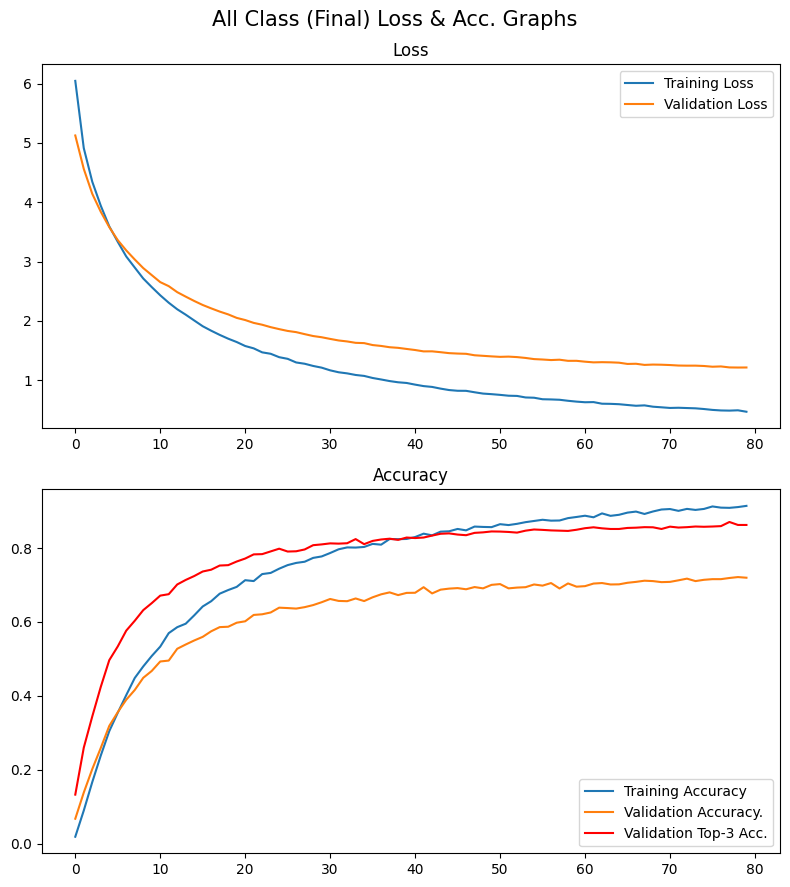

In [ ]:
plt.figure(figsize=(8,9))
plt.suptitle("All Class (Final) Loss & Acc. Graphs",size=15)

plt.subplot(2,1,1)
plt.plot(range(len(history.history["loss"])),history.history["loss"],label="Training Loss")
plt.plot(range(len(history.history["val_loss"])),history.history["val_loss"],label="Validation Loss")
plt.title("Loss")
plt.legend()

plt.subplot(2,1,2)
plt.plot(range(len(history.history["acc"])),history.history["acc"],label="Training Accuracy")
plt.plot(range(len(history.history["val_acc"])),history.history["val_acc"],label="Validation Accuracy.")
plt.plot(range(len(history.history["val_top3_acc"])),history.history["val_top3_acc"],label="Validation Top-3 Acc.",color="red")
plt.title("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

### Test Set

In [ ]:
results = model.evaluate(test_ds, return_dict=True)

print(results)

45/45 ━━━━━━━━━━━━━━━━━━━━ 10s 219ms/step - acc: 0.7171 - loss: 1.2482 - top3_acc: 0.8637
{'acc': 0.7084210515022278, 'loss': 1.2734603881835938, 'top3_acc': 0.856491208076477}


# debugging

In [ ]:
model = load_model("HighRes3.keras")
model.summary()

Model: "HighRes3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 442, 442, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 442, 442, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 442, 442, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 14, 14, 1280)   │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 1280)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 90)             │       115,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,603,856 (9.93 MB)

 Trainable params: 115,290 (450.35 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 230,582 (900.71 KB)

In [ ]:
model.save_weights("HighRes3_weights.weights.h5")

In [ ]:
! unzip -q /content/Highres3_test.zip

In [ ]:
test_ds=tf.keras.utils.image_dataset_from_directory("content/New_Data/test",image_size=(442,442))

Found 946 files belonging to 90 classes.


In [ ]:
for images, labels in test_ds.take(1):
    pass
print(test_ds._input_dataset.class_names[:10])  # should be alphabetical


AttributeError: '_BatchDataset' object has no attribute 'class_names'

In [ ]:
print(test_ds.class_names)

['w0001', 'w0002', 'w0003', 'w0004', 'w0005', 'w0006', 'w0009', 'w0010', 'w0011', 'w0012', 'w0013', 'w0015', 'w0016', 'w0017', 'w0018', 'w0020', 'w0022', 'w0023', 'w0024', 'w0025', 'w0026', 'w0027', 'w0028', 'w0029', 'w0030', 'w0031', 'w0032', 'w0033', 'w0034', 'w0035', 'w0036', 'w0038', 'w0043', 'w0061', 'w0062', 'w0063', 'w0064', 'w0066', 'w0069', 'w0070', 'w0071', 'w0073', 'w0074', 'w0075', 'w0076', 'w0077', 'w0078', 'w0080', 'w0082', 'w0083', 'w0085', 'w0086', 'w0087', 'w0088', 'w0089', 'w0091', 'w0092', 'w0093', 'w0094', 'w0095', 'w0121', 'w0122', 'w0123', 'w0124', 'w0125', 'w0126', 'w0128', 'w0129', 'w0130', 'w0131', 'w0133', 'w0134', 'w0135', 'w0136', 'w0137', 'w0138', 'w0139', 'w0142', 'w0143', 'w0144', 'w0145', 'w0147', 'w0148', 'w0149', 'w0151', 'w0152', 'w0153', 'w0154', 'w0155', 'w0156']
